<a href="https://colab.research.google.com/github/bosnei/fmu/blob/main/N1_MLT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Seção 1: Criação da base de dados**
Referência - [Fraud detection handbook](https://fraud-detection-handbook.github.io/fraud-detection-handbook/Chapter_3_GettingStarted/SimulatedDataset.html)


In [120]:
#Importar bibliotecas
import pandas as pd
import numpy as np
import os
import datetime
import time
import random
from sklearn.model_selection import train_test_split, validation_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, roc_curve, auc, f1_score
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as metrics
import graphviz
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid', {'axes.facecolor': '0.9'})

In [16]:
# Gerando clientes com posições aleatorias
def generate_customer_profiles_table(n_customers, random_state=1):

    np.random.seed(random_state)

    customer_id_properties=[]
    for customer_id in range(n_customers):

        x_customer_id = np.random.uniform(0,100)
        y_customer_id = np.random.uniform(0,100)

        mean_amount = np.random.uniform(5,100)
        std_amount = mean_amount/2

        mean_nb_tx_per_day = np.random.uniform(0,4)

        customer_id_properties.append([customer_id,
                                      x_customer_id, y_customer_id,
                                      mean_amount, std_amount,
                                      mean_nb_tx_per_day])

    customer_profiles_table = pd.DataFrame(customer_id_properties, columns=['CUSTOMER_ID',
                                                                      'x_customer_id', 'y_customer_id',
                                                                      'mean_amount', 'std_amount',
                                                                      'mean_nb_tx_per_day'])

    return customer_profiles_table

# Gerando os terminais e suas posições
def generate_terminal_profiles_table(n_terminals, random_state=1):

    np.random.seed(random_state)

    terminal_id_properties=[]

    for terminal_id in range(n_terminals):

        x_terminal_id = np.random.uniform(0,100)
        y_terminal_id = np.random.uniform(0,100)

        terminal_id_properties.append([terminal_id,
                                      x_terminal_id, y_terminal_id])

    terminal_profiles_table = pd.DataFrame(terminal_id_properties, columns=['TERMINAL_ID',
                                                                      'x_terminal_id', 'y_terminal_id'])

    return terminal_profiles_table

# Gerando a lista de terminais no alcance do cliente
def get_list_terminals_within_radius(customer_profile, x_y_terminals, r):

    x_y_customer = customer_profile[['x_customer_id','y_customer_id']].values.astype(float)
    squared_diff_x_y = np.square(x_y_customer - x_y_terminals)
    dist_x_y = np.sqrt(np.sum(squared_diff_x_y, axis=1))
    available_terminals = list(np.where(dist_x_y<r)[0])

    return available_terminals

def generate_transactions_table(customer_profile, start_date = "2018-04-01", nb_days = 10):

    customer_transactions = []

    random.seed(int(customer_profile.CUSTOMER_ID))
    np.random.seed(int(customer_profile.CUSTOMER_ID))

    for day in range(nb_days):

        nb_tx = np.random.poisson(customer_profile.mean_nb_tx_per_day)

        if nb_tx>0:

            for tx in range(nb_tx):

                # A maioria das transações deve ocorrer durante o dia
                time_tx = int(np.random.normal(86400/2, 20000))

                if (time_tx>0) and (time_tx<86400):

                    amount = np.random.normal(customer_profile.mean_amount, customer_profile.std_amount)

                    if amount<0:
                        amount = np.random.uniform(0,customer_profile.mean_amount*2)

                    amount=np.round(amount,decimals=2)

                    if len(customer_profile.available_terminals)>0:

                        terminal_id = random.choice(customer_profile.available_terminals)

                        customer_transactions.append([time_tx+day*86400, day,
                                                      customer_profile.CUSTOMER_ID,
                                                      terminal_id, amount])

    customer_transactions = pd.DataFrame(customer_transactions, columns=['TX_TIME_SECONDS', 'TX_TIME_DAYS', 'CUSTOMER_ID', 'TERMINAL_ID', 'TX_AMOUNT'])

    if len(customer_transactions)>0:
        customer_transactions['TX_DATETIME'] = pd.to_datetime(customer_transactions["TX_TIME_SECONDS"], unit='s', origin=start_date)
        customer_transactions=customer_transactions[['TX_DATETIME','CUSTOMER_ID', 'TERMINAL_ID', 'TX_AMOUNT','TX_TIME_SECONDS', 'TX_TIME_DAYS']]

    return customer_transactions

# Gerando o dataset
def generate_dataset(n_customers = 10000, n_terminals = 1000000, nb_days=90, start_date="2018-04-01", r=5):

    start_time=time.time()
    customer_profiles_table = generate_customer_profiles_table(n_customers, random_state = 1)
    print("Time to generate customer profiles table: {0:.2}s".format(time.time()-start_time))

    start_time=time.time()
    terminal_profiles_table = generate_terminal_profiles_table(n_terminals, random_state = 1)
    print("Tempo para gerar tabela de terminais: {0:.2}s".format(time.time()-start_time))

    start_time=time.time()
    x_y_terminals = terminal_profiles_table[['x_terminal_id','y_terminal_id']].values.astype(float)
    customer_profiles_table['available_terminals'] = customer_profiles_table.apply(lambda x : get_list_terminals_within_radius(x, x_y_terminals=x_y_terminals, r=r), axis=1)
    customer_profiles_table['nb_terminals']=customer_profiles_table.available_terminals.apply(len)
    print("Tempo para associar terminais aos clientes: {0:.2}s".format(time.time()-start_time))

    start_time=time.time()
    transactions_df=customer_profiles_table.groupby('CUSTOMER_ID').apply(lambda x : generate_transactions_table(x.iloc[0], nb_days=nb_days)).reset_index(drop=True)
    print("Tempo para gerar transações: {0:.2}s".format(time.time()-start_time))

    # Ordenando cronologicamente
    transactions_df=transactions_df.sort_values('TX_DATETIME')
    transactions_df.reset_index(inplace=True,drop=True)
    transactions_df.reset_index(inplace=True)
    transactions_df.rename(columns = {'index':'TRANSACTION_ID'}, inplace = True)

    return (customer_profiles_table, terminal_profiles_table, transactions_df)


In [3]:
# Criando um dataset com 1000 clientes e 2000 terminais, durando 183 dias
(customer_profiles_table, terminal_profiles_table, transactions_df)=\
    generate_dataset(n_customers = 1000,
                     n_terminals = 2000,
                     nb_days=183,
                     start_date="2018-04-01",
                     r=5)

print(f'Shape da tabela gerada: {transactions_df.shape}')

Time to generate customer profiles table: 0.017s
Time to generate terminal profiles table: 0.015s
Time to associate terminals to customers: 0.44s
Time to generate transactions: 1.9e+01s


[Text(0.5, 0, 'Tempo (dias)'), Text(0, 0.5, 'Numero de transações')]

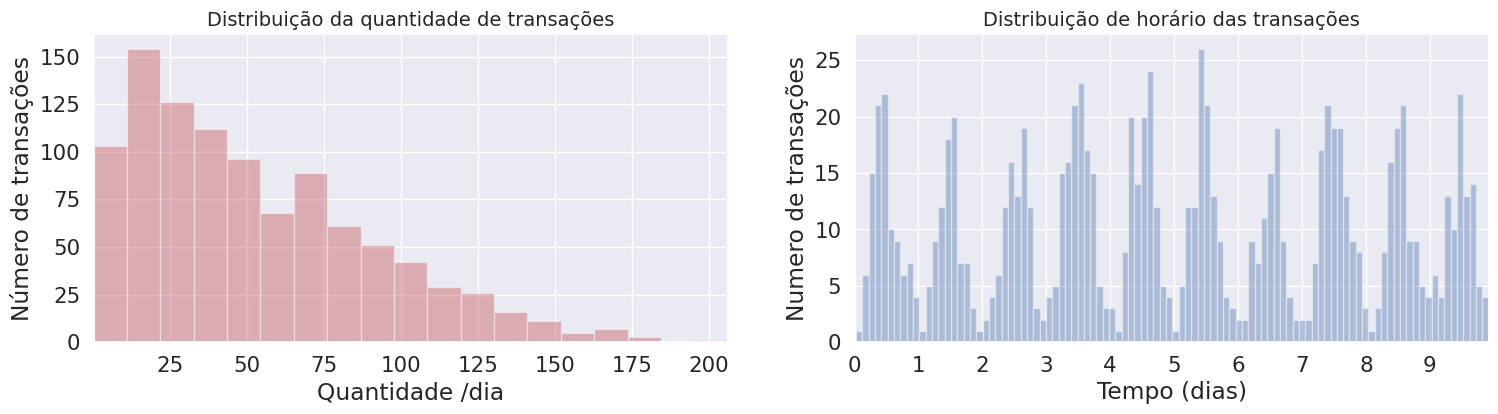

In [21]:
distribution_amount_times_fig, ax = plt.subplots(1, 2, figsize=(18,4))

amount_val = transactions_df[transactions_df.TX_TIME_DAYS<10]['TX_AMOUNT'].sample(n=1000).values
time_val = transactions_df[transactions_df.TX_TIME_DAYS<10]['TX_TIME_SECONDS'].sample(n=1000).values

# Primeiro gráfico mostrando a distribuição da quantidade de transações em um dia
sns.distplot(amount_val, ax=ax[0], color='r', hist = True, kde = False)
ax[0].set_title('Distribuição da quantidade de transações', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])
ax[0].set(xlabel = "Quantidade /dia", ylabel="Número de transações")

# Segundo gráfico mostrando a que horas as transações ocorrem
sns.distplot(time_val/86400, ax=ax[1], color='b', bins = 100, hist = True, kde = False)
ax[1].set_title('Distribuição de horário das transações', fontsize=14)
ax[1].set_xlim([min(time_val/86400), max(time_val/86400)])
ax[1].set_xticks(range(10))
ax[1].set(xlabel = "Tempo (dias)", ylabel="Numero de transações")

##**1.1 Adicionando casos de fraude na base**


In [18]:
def add_frauds(customer_profiles_table, terminal_profiles_table, transactions_df):

    # Marcando todas transações como genuínas
    transactions_df['TX_FRAUD']=0
    transactions_df['TX_FRAUD_SCENARIO']=0

    # Cenário 1: Transações com alto valor
    transactions_df.loc[transactions_df.TX_AMOUNT>220, 'TX_FRAUD']=1
    transactions_df.loc[transactions_df.TX_AMOUNT>220, 'TX_FRAUD_SCENARIO']=1
    nb_frauds_scenario_1=transactions_df.TX_FRAUD.sum()
    print("Número de fraudes no cenário 1: "+str(nb_frauds_scenario_1))

    # Cenário 2: Um terminal a cada 28 dias, é marcado como fráudulo
    for day in range(transactions_df.TX_TIME_DAYS.max()):

        compromised_terminals = terminal_profiles_table.TERMINAL_ID.sample(n=1, random_state=day)

        compromised_transactions=transactions_df[(transactions_df.TX_TIME_DAYS>=day) &
                                                    (transactions_df.TX_TIME_DAYS<day+28) &
                                                    (transactions_df.TERMINAL_ID.isin(compromised_terminals))]

        transactions_df.loc[compromised_transactions.index,'TX_FRAUD']=1
        transactions_df.loc[compromised_transactions.index,'TX_FRAUD_SCENARIO']=2

    nb_frauds_scenario_2=transactions_df.TX_FRAUD.sum()-nb_frauds_scenario_1
    print("Número de fraudes no cenário 2: "+str(nb_frauds_scenario_2))

    # Cenário 3: A cada 14 dias, um cliente tem 1/3 de suas transações multiplicadas por 5
    for day in range(transactions_df.TX_TIME_DAYS.max()):

        compromised_customers = customer_profiles_table.CUSTOMER_ID.sample(n=1, random_state=day).values

        compromised_transactions=transactions_df[(transactions_df.TX_TIME_DAYS>=day) &
                                                    (transactions_df.TX_TIME_DAYS<day+14) &
                                                    (transactions_df.CUSTOMER_ID.isin(compromised_customers))]

        nb_compromised_transactions=len(compromised_transactions)


        random.seed(day)
        index_fauds = random.sample(list(compromised_transactions.index.values),k=int(nb_compromised_transactions/3))

        transactions_df.loc[index_fauds,'TX_AMOUNT']=transactions_df.loc[index_fauds,'TX_AMOUNT']*5
        transactions_df.loc[index_fauds,'TX_FRAUD']=1
        transactions_df.loc[index_fauds,'TX_FRAUD_SCENARIO']=3


    nb_frauds_scenario_3=transactions_df.TX_FRAUD.sum()-nb_frauds_scenario_2-nb_frauds_scenario_1
    print("Número de fraudes no cenário 3: "+str(nb_frauds_scenario_3))

    return transactions_df

In [13]:
transactions_df = add_frauds(customer_profiles_table, terminal_profiles_table, transactions_df)
print(f'Porcentagem de fraudes: {transactions_df.TX_FRAUD.mean()*100:.2f}%')
print(f'Quantidade total de fraudes: {transactions_df.TX_FRAUD.sum()}')

Número de fraudes no cenário 1: 987
Número de fraudes no cenário 2: 4781
Número de fraudes no cenário 3: 701
Porcentagem de fraudes: 1.77%
Quantidade total de fraudes: 6469


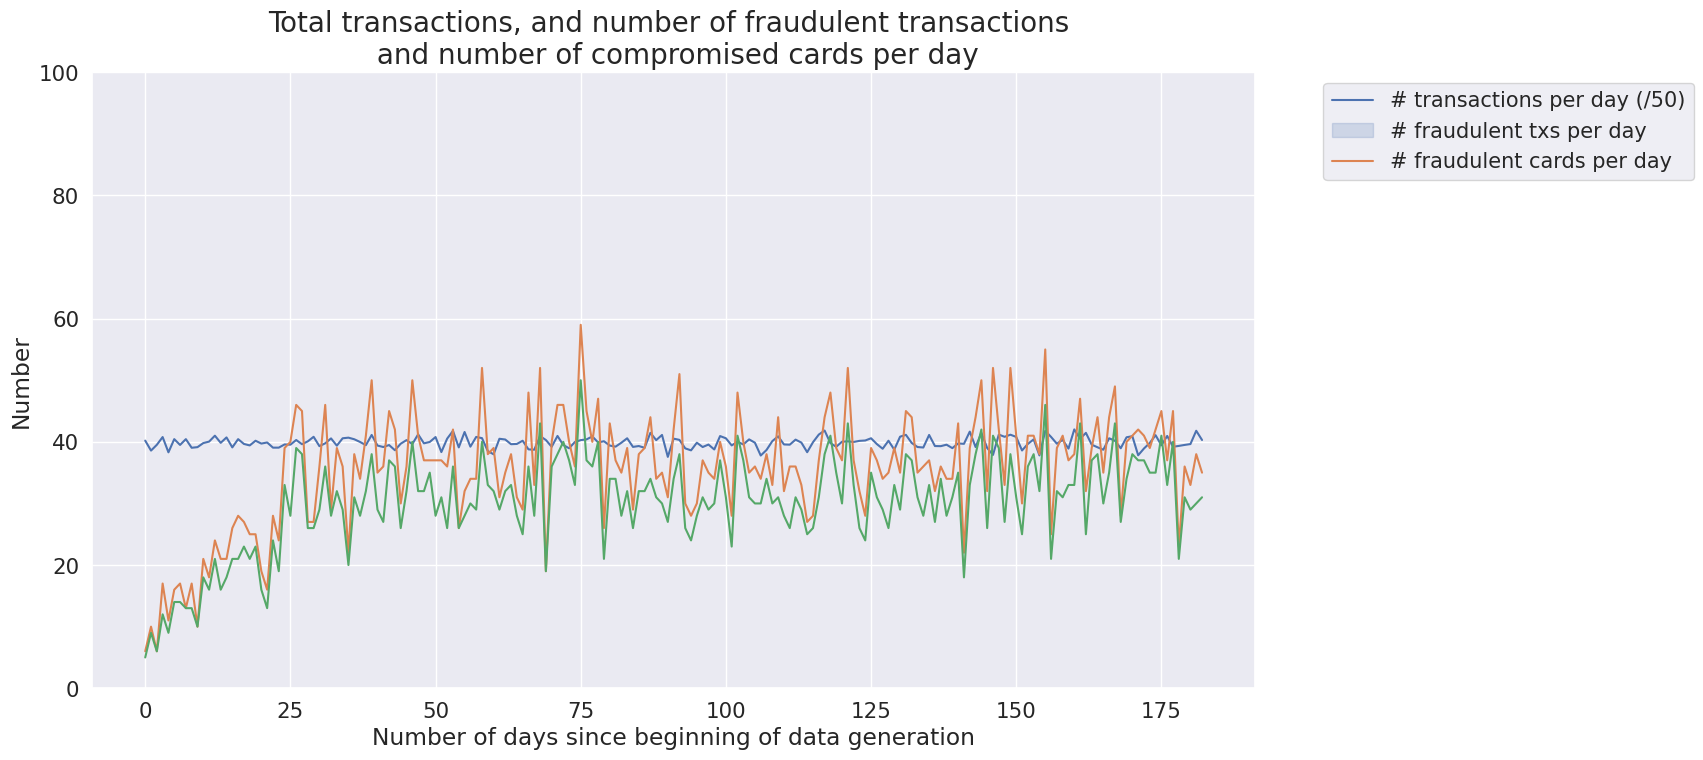

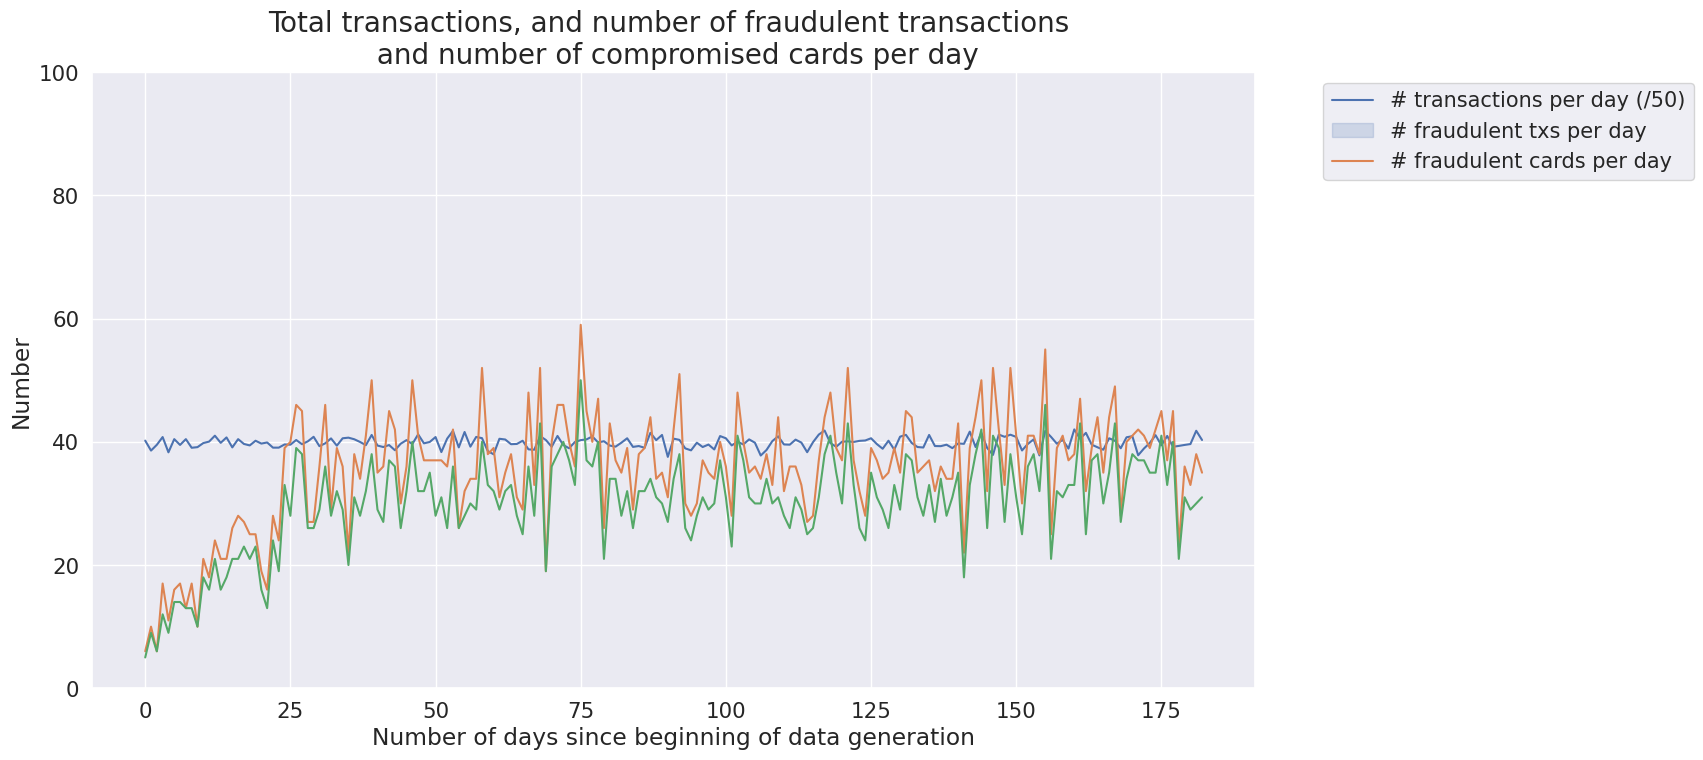

In [20]:
def get_stats(transactions_df):
    #Number of transactions per day
    nb_tx_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['CUSTOMER_ID'].count()
    #Number of fraudulent transactions per day
    nb_fraud_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['TX_FRAUD'].sum()
    #Number of fraudulent cards per day
    nb_fraudcard_per_day=transactions_df[transactions_df['TX_FRAUD']>0].groupby(['TX_TIME_DAYS']).CUSTOMER_ID.nunique()

    return (nb_tx_per_day,nb_fraud_per_day,nb_fraudcard_per_day)

(nb_tx_per_day,nb_fraud_per_day,nb_fraudcard_per_day)=get_stats(transactions_df)

n_days=len(nb_tx_per_day)
tx_stats=pd.DataFrame({"value":pd.concat([nb_tx_per_day/50,nb_fraud_per_day,nb_fraudcard_per_day])})
tx_stats['stat_type']=["nb_tx_per_day"]*n_days+["nb_fraud_per_day"]*n_days+["nb_fraudcard_per_day"]*n_days
tx_stats=tx_stats.reset_index()


sns.set(style='darkgrid')
sns.set(font_scale=1.4)

fraud_and_transactions_stats_fig = plt.gcf()

fraud_and_transactions_stats_fig.set_size_inches(15, 8)

sns_plot = sns.lineplot(x="TX_TIME_DAYS", y="value", data=tx_stats, hue="stat_type", hue_order=["nb_tx_per_day","nb_fraud_per_day","nb_fraudcard_per_day"], legend=False)

sns_plot.set_title('Total transactions, and number of fraudulent transactions \n and number of compromised cards per day', fontsize=20)
sns_plot.set(xlabel = "Number of days since beginning of data generation", ylabel="Number")

sns_plot.set_ylim([0,100])

labels_legend = ["# transactions per day (/50)", "# fraudulent txs per day", "# fraudulent cards per day"]

sns_plot.legend(loc='upper left', labels=labels_legend,bbox_to_anchor=(1.05, 1), fontsize=15)

fraud_and_transactions_stats_fig

##**1.2 Feature Engineering**

In [22]:
#Feature Engineering

# Define se o dia é um final de semana
def is_weekend(tx_datetime):
    weekday = tx_datetime.weekday()
    is_weekend = weekday>=5

    return int(is_weekend)

transactions_df['TX_DURING_WEEKEND']=transactions_df.TX_DATETIME.apply(is_weekend)

# Define se a transação ocorreu de dia ou à noite
def is_night(tx_datetime):

    tx_hour = tx_datetime.hour
    is_night = tx_hour<=6

    return int(is_night)

transactions_df['TX_DURING_NIGHT']=transactions_df.TX_DATETIME.apply(is_night)

# Gerando 6 features que mostram o comportamento usual do cliente
def get_customer_spending_behaviour_features(customer_transactions, windows_size_in_days=[1,7,30]):

    customer_transactions=customer_transactions.sort_values('TX_DATETIME')

    customer_transactions.index=customer_transactions.TX_DATETIME

    for window_size in windows_size_in_days:

        SUM_AMOUNT_TX_WINDOW=customer_transactions['TX_AMOUNT'].rolling(str(window_size)+'d').sum()
        NB_TX_WINDOW=customer_transactions['TX_AMOUNT'].rolling(str(window_size)+'d').count()

        AVG_AMOUNT_TX_WINDOW=SUM_AMOUNT_TX_WINDOW/NB_TX_WINDOW

        customer_transactions['CUSTOMER_ID_NB_TX_'+str(window_size)+'DAY_WINDOW']=list(NB_TX_WINDOW)
        customer_transactions['CUSTOMER_ID_AVG_AMOUNT_'+str(window_size)+'DAY_WINDOW']=list(AVG_AMOUNT_TX_WINDOW)

    customer_transactions.index=customer_transactions.TRANSACTION_ID

    return customer_transactions

transactions_df=transactions_df.groupby('CUSTOMER_ID').apply(lambda x: get_customer_spending_behaviour_features(x, windows_size_in_days=[1,7,30]))
transactions_df=transactions_df.sort_values('TX_DATETIME').reset_index(drop=True)

# Gerando features que calculam o risco de cada terminal ter sido compremetido
def get_count_risk_rolling_window(terminal_transactions, delay_period=7, windows_size_in_days=[1,7,30], feature="TERMINAL_ID"):

    terminal_transactions=terminal_transactions.sort_values('TX_DATETIME')

    terminal_transactions.index=terminal_transactions.TX_DATETIME

    NB_FRAUD_DELAY=terminal_transactions['TX_FRAUD'].rolling(str(delay_period)+'d').sum()
    NB_TX_DELAY=terminal_transactions['TX_FRAUD'].rolling(str(delay_period)+'d').count()

    for window_size in windows_size_in_days:

        NB_FRAUD_DELAY_WINDOW=terminal_transactions['TX_FRAUD'].rolling(str(delay_period+window_size)+'d').sum()
        NB_TX_DELAY_WINDOW=terminal_transactions['TX_FRAUD'].rolling(str(delay_period+window_size)+'d').count()

        NB_FRAUD_WINDOW=NB_FRAUD_DELAY_WINDOW-NB_FRAUD_DELAY
        NB_TX_WINDOW=NB_TX_DELAY_WINDOW-NB_TX_DELAY

        RISK_WINDOW=NB_FRAUD_WINDOW/NB_TX_WINDOW

        terminal_transactions[feature+'_NB_TX_'+str(window_size)+'DAY_WINDOW']=list(NB_TX_WINDOW)
        terminal_transactions[feature+'_RISK_'+str(window_size)+'DAY_WINDOW']=list(RISK_WINDOW)

    terminal_transactions.index=terminal_transactions.TRANSACTION_ID
    terminal_transactions.fillna(0,inplace=True)

    return terminal_transactions

transactions_df=transactions_df.groupby('TERMINAL_ID').apply(lambda x: get_count_risk_rolling_window(x, delay_period=7, windows_size_in_days=[1,7,30], feature="TERMINAL_ID"))
transactions_df=transactions_df.sort_values('TX_DATETIME').reset_index(drop=True)

print(f'Shape da tabela com as novas features: {transactions_df.shape}')

In [27]:
print(f'Shape da tabela com as novas features: {transactions_df.shape}')
transactions_df

Shape da tabela com as novas features: (364964, 23)


,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,TX_DURING_WEEKEND,...,CUSTOMER_ID_NB_TX_7DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW,CUSTOMER_ID_NB_TX_30DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW,TERMINAL_ID_NB_TX_1DAY_WINDOW,TERMINAL_ID_RISK_1DAY_WINDOW,TERMINAL_ID_NB_TX_7DAY_WINDOW,TERMINAL_ID_RISK_7DAY_WINDOW,TERMINAL_ID_NB_TX_30DAY_WINDOW,TERMINAL_ID_RISK_30DAY_WINDOW
0,0,2018-04-01 00:00:31,596,474,66.50,31,0,0,0,1,...,1.0,66.500000,1.0,66.500000,0.0,0.0,0.0,0.000000,0.0,0.000000
1,1,2018-04-01 00:03:12,53,1223,15.11,192,0,0,0,1,...,1.0,15.110000,1.0,15.110000,0.0,0.0,0.0,0.000000,0.0,0.000000
2,2,2018-04-01 00:07:08,815,16,41.15,428,0,0,0,1,...,1.0,41.150000,1.0,41.150000,0.0,0.0,0.0,0.000000,0.0,0.000000
3,3,2018-04-01 00:07:56,2,1717,81.58,476,0,0,0,1,...,1.0,81.580000,1.0,81.580000,0.0,0.0,0.0,0.000000,0.0,0.000000
4,4,2018-04-01 00:09:07,997,922,14.90,547,0,0,0,1,...,1.0,14.900000,1.0,14.900000,0.0,0.0,0.0,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
364959,364959,2018-09-30 23:40:06,907,1137,115.43,15810006,182,0,0,1,...,3.0,87.423333,12.0,67.460833,1.0,0.0,6.0,0.000000,32.0,0.000000
364960,364960,2018-09-30 23:44:09,55,1253,7.36,15810249,182,0,0,1,...,31.0,20.162258,113.0,18.495044,0.0,0.0,2.0,0.000000,33.0,0.000000
364961,364961,2018-09-30 23:47:41,316,875,31.15,15810461,182,0,0,1,...,9.0,70.767778,34.0,63.090882,1.0,0.0,6.0,0.000000,36.0,0.027778
364962,364962,2018-09-30 23:51:12,49,61,98.27,15810672,182,0,0,1,...,36.0,66.885556,129.0,65.244264,2.0,0.0,14.0,0.000000,62.0,0.000000


#**Seção 2: Preparando os dados para o modelo**

In [51]:
# Utilizando um período de 3 semanas para o modelo como teste
BEGIN_DATE = "2018-07-25"
END_DATE = "2018-08-14"
start_date_filtered = pd.to_datetime(BEGIN_DATE)
end_date_filtered = pd.to_datetime(END_DATE)

transactions_df_specific_period = transactions_df[
    (transactions_df.TX_DATETIME >= start_date_filtered) &
    (transactions_df.TX_DATETIME < end_date_filtered)
]

print(f'Shape do período especificado: {transactions_df_specific_period.shape}')

Shape do período especificado: (40024, 23)


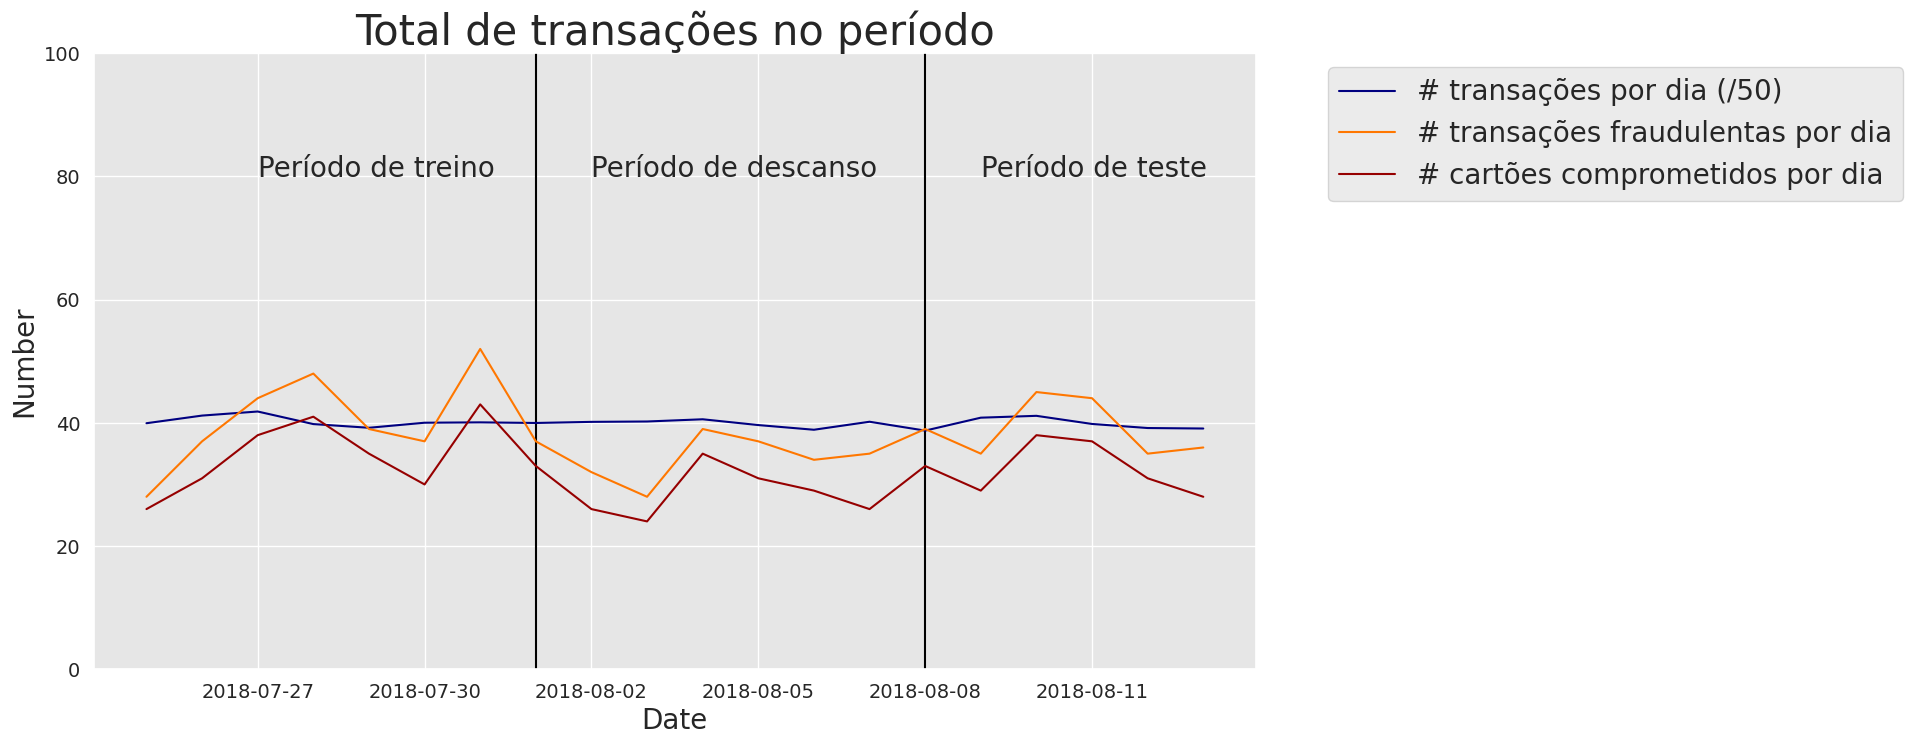

In [63]:
def get_tx_stats(transactions_df_specific_period, start_date_df="2018-04-01"):
    nb_tx_per_day=transactions_df_specific_period.groupby(['TX_TIME_DAYS'])['CUSTOMER_ID'].count()
    nb_fraudulent_transactions_per_day=transactions_df_specific_period.groupby(['TX_TIME_DAYS'])['TX_FRAUD'].sum()
    nb_compromised_cards_per_day=transactions_df_specific_period[transactions_df_specific_period['TX_FRAUD']==1].groupby(['TX_TIME_DAYS']).CUSTOMER_ID.nunique()

    tx_stats=pd.DataFrame({"nb_tx_per_day":nb_tx_per_day,
                           "nb_fraudulent_transactions_per_day":nb_fraudulent_transactions_per_day,
                           "nb_compromised_cards_per_day":nb_compromised_cards_per_day})

    tx_stats=tx_stats.reset_index()

    start_date = datetime.datetime.strptime(start_date_df, "%Y-%m-%d")
    tx_date=start_date+tx_stats['TX_TIME_DAYS'].apply(datetime.timedelta)

    tx_stats['tx_date']=tx_date

    return tx_stats

tx_stats=get_tx_stats(transactions_df_specific_period, start_date_df="2018-04-01")

def get_template_tx_stats(ax ,fs,
                          start_date_training,
                          title='',
                          delta_train=7,
                          delta_delay=7,
                          delta_test=7,
                          ylim=100):

    ax.set_title(title, fontsize=fs*1.5)
    ax.set_ylim([0, ylim])

    ax.set_xlabel('Date', fontsize=fs)
    ax.set_ylabel('Number', fontsize=fs)

    plt.yticks(fontsize=fs*0.7)
    plt.xticks(fontsize=fs*0.7)

    ax.axvline(start_date_training+datetime.timedelta(days=delta_train), 0,ylim, color="black")
    ax.axvline(start_date_test, 0, ylim, color="black")

    ax.text(start_date_training+datetime.timedelta(days=2), ylim-20,'Período de treino', fontsize=fs)
    ax.text(start_date_training+datetime.timedelta(days=delta_train+1), ylim-20,'Período de descanso', fontsize=fs)
    ax.text(start_date_training+datetime.timedelta(days=delta_train+delta_delay+1), ylim-20,'Período de teste', fontsize=fs)


cmap = plt.get_cmap('jet')
colors={'nb_tx_per_day':cmap(0),
        'nb_fraudulent_transactions_per_day':cmap(200),
        'nb_compromised_cards_per_day':cmap(250)}

fraud_and_transactions_stats_fig, ax = plt.subplots(1, 1, figsize=(15,8))

# Training period
start_date_training = datetime.datetime.strptime("2018-07-25", "%Y-%m-%d")
delta_train = delta_delay = delta_test = 7

end_date_training = start_date_training+datetime.timedelta(days=delta_train-1)

# Test period
start_date_test = start_date_training+datetime.timedelta(days=delta_train+delta_delay)
end_date_test = start_date_training+datetime.timedelta(days=delta_train+delta_delay+delta_test-1)

get_template_tx_stats(ax, fs=20,
                      start_date_training=start_date_training,
                      title='Total de transações no período',
                      delta_train=delta_train,
                      delta_delay=delta_delay,
                      delta_test=delta_test
                     )

ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

ax.plot(tx_stats['tx_date'], tx_stats['nb_tx_per_day']/50, 'b', color=colors['nb_tx_per_day'], label = '# transações por dia (/50)')
ax.plot(tx_stats['tx_date'], tx_stats['nb_fraudulent_transactions_per_day'], 'b', color=colors['nb_fraudulent_transactions_per_day'], label = '# transações fraudulentas por dia')
ax.plot(tx_stats['tx_date'], tx_stats['nb_compromised_cards_per_day'], 'b', color=colors['nb_compromised_cards_per_day'], label = '# cartões comprometidos por dia')

ax.legend(loc = 'upper left',bbox_to_anchor=(1.05, 1),fontsize=20)

#**Seção 3: Treinando o modelo**

In [55]:
# Training period
start_date_training = datetime.datetime.strptime("2018-07-25", "%Y-%m-%d")
delta_train = delta_delay = delta_test = 7

end_date_training = start_date_training+datetime.timedelta(days=delta_train-1)

# Test period
start_date_test = start_date_training+datetime.timedelta(days=delta_train+delta_delay)
end_date_test = start_date_training+datetime.timedelta(days=delta_train+delta_delay+delta_test-1)

def get_train_test_set(transactions_df_specific_period,
                       start_date_training,
                       delta_train=7,delta_delay=7,delta_test=7):

    # Get the training set data
    train_df = transactions_df_specific_period[(transactions_df_specific_period.TX_DATETIME>=start_date_training) &
                               (transactions_df_specific_period.TX_DATETIME<start_date_training+datetime.timedelta(days=delta_train))]

    # Get the test set data
    test_df = []

    # Note: Cards known to be compromised after the delay period are removed from the test set
    # That is, for each test day, all frauds known at (test_day-delay_period) are removed

    # First, get known defrauded customers from the training set
    known_defrauded_customers = set(train_df[train_df.TX_FRAUD==1].CUSTOMER_ID)

    # Get the relative starting day of training set (easier than TX_DATETIME to collect test data)
    start_tx_time_days_training = train_df.TX_TIME_DAYS.min()

    # Then, for each day of the test set
    for day in range(delta_test):

        # Get test data for that day
        test_df_day = transactions_df_specific_period[transactions_df_specific_period.TX_TIME_DAYS==start_tx_time_days_training+
                                                                    delta_train+delta_delay+
                                                                    day]

        # Compromised cards from that test day, minus the delay period, are added to the pool of known defrauded customers
        test_df_day_delay_period = transactions_df_specific_period[transactions_df_specific_period.TX_TIME_DAYS==start_tx_time_days_training+
                                                                                delta_train+
                                                                                day-1]

        new_defrauded_customers = set(test_df_day_delay_period[test_df_day_delay_period.TX_FRAUD==1].CUSTOMER_ID)
        known_defrauded_customers = known_defrauded_customers.union(new_defrauded_customers)

        test_df_day = test_df_day[~test_df_day.CUSTOMER_ID.isin(known_defrauded_customers)]

        test_df.append(test_df_day)

    test_df = pd.concat(test_df)

    # Sort data sets by ascending order of transaction ID
    train_df=train_df.sort_values('TRANSACTION_ID')
    test_df=test_df.sort_values('TRANSACTION_ID')

    return (train_df, test_df)

(train_df, test_df)=get_train_test_set(transactions_df_specific_period,start_date_training,
                                       delta_train=7,delta_delay=7,delta_test=7)

print(f'Shape do dataset de treino: {train_df.shape}')
print(f'Shape do dataset de teste: {test_df.shape}')

Shape do dataset de treino: (14103, 23)
Shape do dataset de teste: (9480, 23)


##**Árvore de decisão**


In [57]:
output_feature="TX_FRAUD"

input_features=['TX_AMOUNT','TX_DURING_WEEKEND', 'TX_DURING_NIGHT', 'CUSTOMER_ID_NB_TX_1DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW', 'CUSTOMER_ID_NB_TX_7DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW', 'CUSTOMER_ID_NB_TX_30DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW', 'TERMINAL_ID_NB_TX_1DAY_WINDOW',
       'TERMINAL_ID_RISK_1DAY_WINDOW', 'TERMINAL_ID_NB_TX_7DAY_WINDOW',
       'TERMINAL_ID_RISK_7DAY_WINDOW', 'TERMINAL_ID_NB_TX_30DAY_WINDOW',
       'TERMINAL_ID_RISK_30DAY_WINDOW']

def fit_model_and_get_predictions(classifier, train_df, test_df,
                                  input_features, output_feature="TX_FRAUD",scale=True):

    if scale:
        (train_df, test_df)=scaleData(train_df,test_df,input_features)

    start_time=time.time()
    classifier.fit(train_df[input_features], train_df[output_feature])
    training_execution_time=time.time()-start_time

    start_time=time.time()
    predictions_test=classifier.predict_proba(test_df[input_features])[:,1]
    prediction_execution_time=time.time()-start_time

    predictions_train=classifier.predict_proba(train_df[input_features])[:,1]

    model_and_predictions_dictionary = {'classifier': classifier,
                                        'predictions_test': predictions_test,
                                        'predictions_train': predictions_train,
                                        'training_execution_time': training_execution_time,
                                        'prediction_execution_time': prediction_execution_time
                                       }

    return model_and_predictions_dictionary

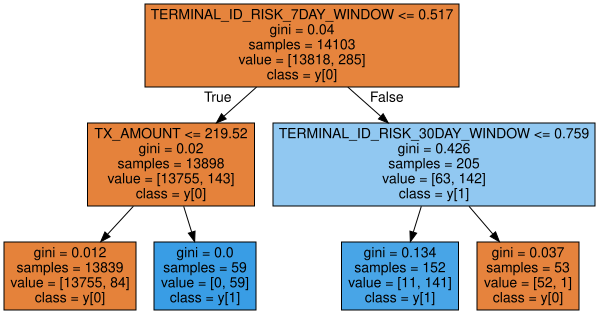

In [59]:
classifier = sklearn.tree.DecisionTreeClassifier(max_depth = 2, random_state=0)

model_and_predictions_dictionary = fit_model_and_get_predictions(classifier, train_df, test_df,
                                                                 input_features, output_feature,
                                                                 scale=False)

display(graphviz.Source(sklearn.tree.export_graphviz(classifier,feature_names=input_features,class_names=True, filled=True)))

In [60]:
test_df['TX_FRAUD_PREDICTED']=model_and_predictions_dictionary['predictions_test']
test_df.head()
print(f'')

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,TX_DURING_WEEKEND,...,CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW,CUSTOMER_ID_NB_TX_30DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW,TERMINAL_ID_NB_TX_1DAY_WINDOW,TERMINAL_ID_RISK_1DAY_WINDOW,TERMINAL_ID_NB_TX_7DAY_WINDOW,TERMINAL_ID_RISK_7DAY_WINDOW,TERMINAL_ID_NB_TX_30DAY_WINDOW,TERMINAL_ID_RISK_30DAY_WINDOW,TX_FRAUD_PREDICTED
257060,257060,2018-08-08 00:03:11,529,1478,17.23,11145791,129,0,0,0,...,48.059524,85.0,52.275529,3.0,0.0,12.0,0.0,44.0,0.0,0.00607
257062,257062,2018-08-08 00:12:06,541,1720,52.22,11146326,129,0,0,0,...,46.526000,56.0,47.785179,1.0,0.0,9.0,0.0,43.0,0.0,0.00607
257063,257063,2018-08-08 00:14:09,858,1095,42.22,11146449,129,0,0,0,...,44.100000,66.0,40.368030,1.0,0.0,5.0,0.0,23.0,0.0,0.00607
257064,257064,2018-08-08 00:21:41,340,1921,8.64,11146901,129,0,0,0,...,6.283333,25.0,9.224800,1.0,0.0,10.0,0.0,23.0,0.0,0.00607
257065,257065,2018-08-08 00:26:40,965,6,136.11,11147200,129,0,0,0,...,77.532353,127.0,68.362677,0.0,0.0,8.0,0.0,33.0,0.0,0.00607


##**Avaliação do modelo**

Acurácia: 0.9944
Precisão: 0.8689
Recall: 0.5408

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9382
           1       0.87      0.54      0.67        98

    accuracy                           0.99      9480
   macro avg       0.93      0.77      0.83      9480
weighted avg       0.99      0.99      0.99      9480



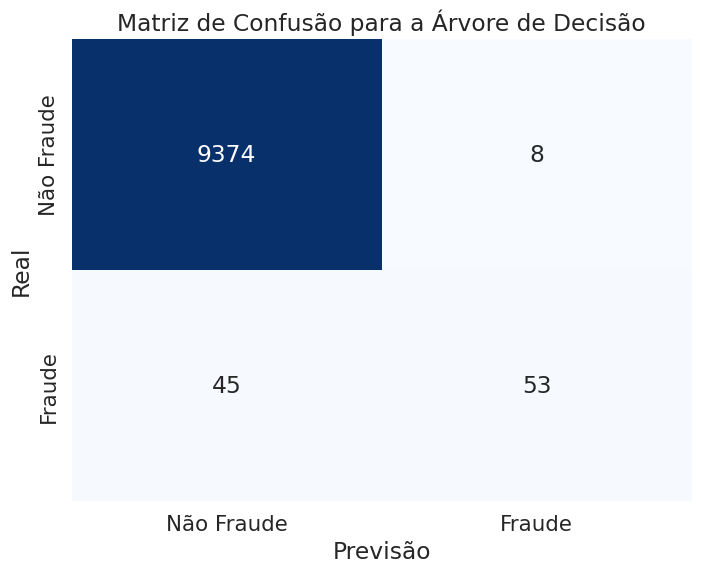

Acurácia não é um bom métrico para um modelo desbalanceado (os dados de treino já são 99% verdadeiros, logo a alta acurácia não significa nada)

9374 Verdadeiros positivos 
53 Verdadeiros negativos 
8 Falsos positivos 
45 Falsos negativos
Com alta precisão e baixo recall, o modelo irá identificar poucos casos, porém os identificados serão, por maioria, corretos


In [123]:
# Transformando os dados em binário
test_df['TX_FRAUD_BINARY_PRED'] = (test_df['TX_FRAUD_PREDICTED'] > 0.5).astype(int)

# Acurácia
accuracy = accuracy_score(test_df['TX_FRAUD'], test_df['TX_FRAUD_BINARY_PRED'])
print(f"Acurácia: {accuracy:.4f}")

# Precisão
precision = precision_score(test_df['TX_FRAUD'], test_df['TX_FRAUD_BINARY_PRED'])
print(f"Precisão: {precision:.4f}")

# Recall
recall = recall_score(test_df['TX_FRAUD'], test_df['TX_FRAUD_BINARY_PRED'])
print(f"Recall: {recall:.4f}")

# Display Classification Report
print("\nClassification Report:")
print(classification_report(test_df['TX_FRAUD'], test_df['TX_FRAUD_BINARY_PRED']))

# Matriz de confusão

cm = confusion_matrix(test_df['TX_FRAUD'], test_df['TX_FRAUD_BINARY_PRED'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Não Fraude', 'Fraude'],
            yticklabels=['Não Fraude', 'Fraude'])
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão para a Árvore de Decisão')
plt.show()

print('Acurácia não é um bom métrico para um modelo desbalanceado (os dados de treino já são 99% verdadeiros, logo a alta acurácia não significa nada)\n')
print(f'{cm[0,0]} Verdadeiros positivos \n{cm[1,1]} Verdadeiros negativos \n{cm[0,1]} Falsos positivos \n{cm[1,0]} Falsos negativos')
print('Com alta precisão e baixo recall, o modelo irá identificar poucos casos, porém os identificados serão, por sua maioria, corretos')

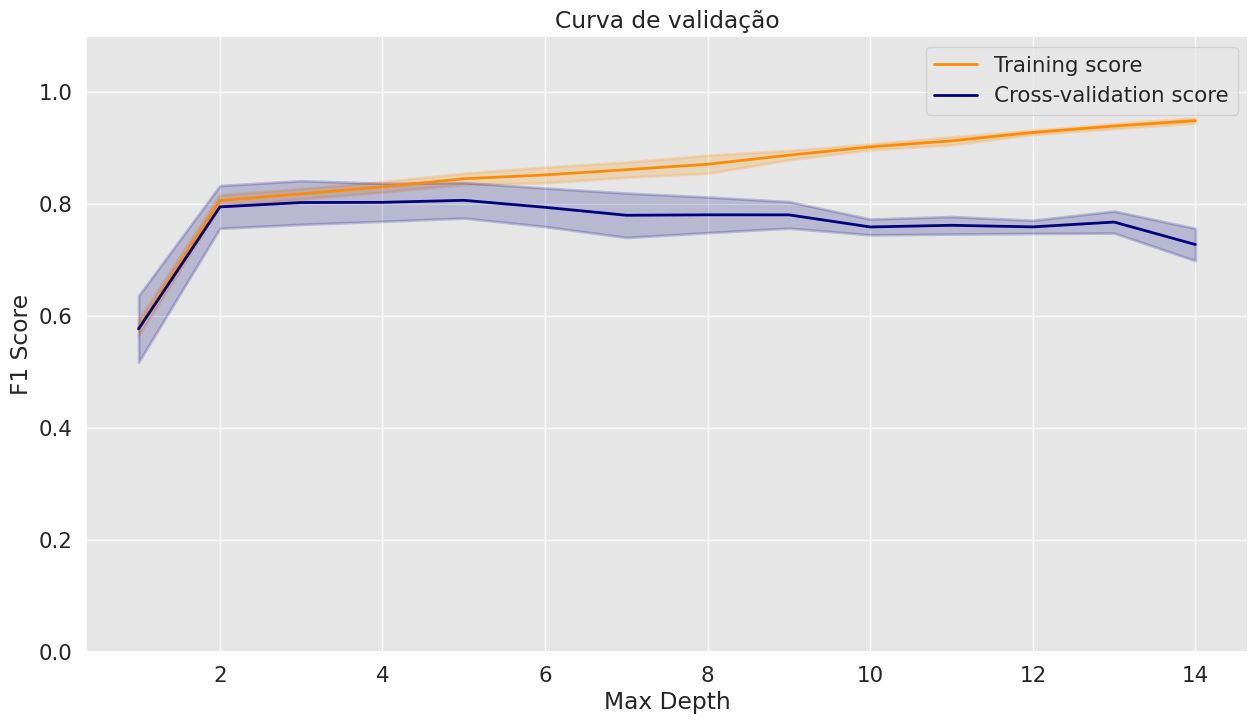

In [82]:
# Curva de validação
param_range = np.arange(1, 15)
train_scores, test_scores = validation_curve(
    classifier,
    train_df[input_features],
    train_df[output_feature],
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)

test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.figure(figsize=(15, 8))
plt.title("Curva de validação")
plt.xlabel("Max Depth")
plt.ylabel("F1 Score")
plt.ylim(0.0, 1.1)

plt.plot(param_range, train_scores_mean, label="Training score", color="darkorange", lw=2)
plt.fill_between(param_range, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2, color="darkorange", lw=2)
plt.plot(param_range, test_scores_mean, label="Cross-validation score", color="navy", lw=2)
plt.fill_between(param_range, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.2, color="navy", lw=2)

plt.legend(loc="best")
plt.grid(True)
plt.show()

best_depth_idx = np.argmax(test_scores_mean)
best_depth = param_range[best_depth_idx]

print(f"A melhor profundidade (max_depth) para a árvore de decisão, com base na pontuação F1 média do cross-validation, é: {best_depth}")

In [136]:
# Fazendo a árvore com profundidade 5
classifier_depth_5 = sklearn.tree.DecisionTreeClassifier(max_depth=5, random_state=0)

model_and_predictions_depth_5 = fit_model_and_get_predictions(classifier_depth_5, train_df, test_df,
                                                                 input_features, output_feature,
                                                                 scale=False)

predictions_df_depth_5=test_df.copy()

Acurácia para profundidade 5: 0.9940
Recall para profundidade 5: 0.5816
Precisão para profundidade 5: 0.7808
F1-score para profundidade 5:0.6667


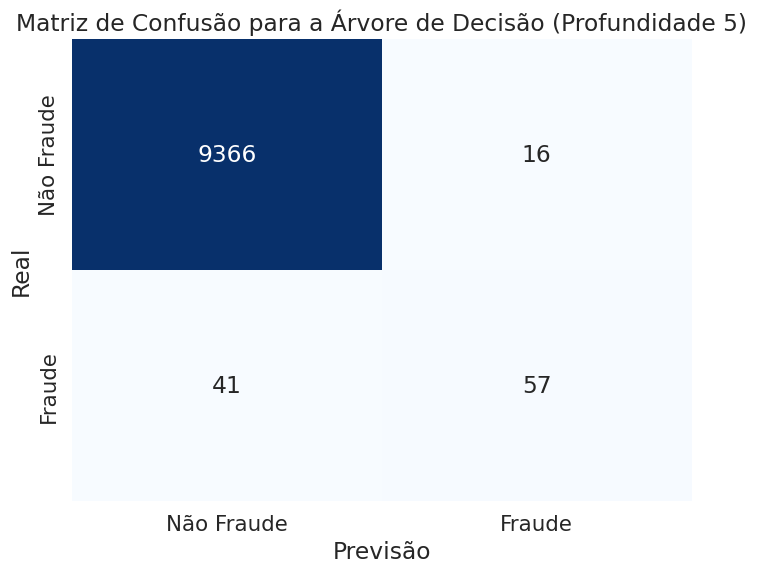

9366 Verdadeiros positivos 
57 Verdadeiros negativos 
16 Falsos positivos 
41 Falsos negativos
O novo modelo possui uma precisão menor, porém um recall maior, sendo melhor para um sistema com 
uma segunda camada de segurança, podendo identificar mais casos de fraude


In [128]:
accuracy_depth_5 = accuracy_score(predictions_df_depth_5['TX_FRAUD'], predictions_df_depth_5['TX_FRAUD_BINARY_PRED'])
recall_depth_5 = recall_score(predictions_df_depth_5['TX_FRAUD'], predictions_df_depth_5['TX_FRAUD_BINARY_PRED'])
precision_depth_5 = precision_score(predictions_df_depth_5['TX_FRAUD'], predictions_df_depth_5['TX_FRAUD_BINARY_PRED'])
f1_score_depth_5 = f1_score(predictions_df_depth_5['TX_FRAUD'], predictions_df_depth_5['TX_FRAUD_BINARY_PRED'])

print(f"Acurácia para profundidade 5: {accuracy_depth_5:.4f}")
print(f"Recall para profundidade 5: {recall_depth_5:.4f}")
print(f"Precisão para profundidade 5: {precision_depth_5:.4f}")
print(f"F1-score para profundidade 5:{f1_score_depth_5:.4f}")

predictions_df_depth_5['TX_FRAUD_BINARY_PRED'] = (predictions_df_depth_5['predictions'] > 0.5).astype(int)

cm_depth_5 = confusion_matrix(predictions_df_depth_5['TX_FRAUD'], predictions_df_depth_5['TX_FRAUD_BINARY_PRED'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_depth_5, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Não Fraude', 'Fraude'],
            yticklabels=['Não Fraude', 'Fraude'])
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão para a Árvore de Decisão (Profundidade 5)')
plt.show()

print(f'{cm_depth_5[0,0]} Verdadeiros positivos \n{cm_depth_5[1,1]} Verdadeiros negativos \n{cm_depth_5[0,1]} Falsos positivos \n{cm_depth_5[1,0]} Falsos negativos')
print('O novo modelo possui uma precisão menor, porém um recall maior, sendo melhor para um sistema com \numa segunda camada de segurança, podendo identificar mais casos de fraude')

In [83]:
def card_precision_top_k_day(df_day,top_k):

    # This takes the max of the predictions AND the max of label TX_FRAUD for each CUSTOMER_ID,
    # and sorts by decreasing order of fraudulent prediction
    df_day = df_day.groupby('CUSTOMER_ID').max().sort_values(by="predictions", ascending=False).reset_index(drop=False)

    # Get the top k most suspicious cards
    df_day_top_k=df_day.head(top_k)
    list_detected_compromised_cards=list(df_day_top_k[df_day_top_k.TX_FRAUD==1].CUSTOMER_ID)

    # Compute precision top k
    card_precision_top_k = len(list_detected_compromised_cards) / top_k

    return list_detected_compromised_cards, card_precision_top_k

def card_precision_top_k(predictions_df, top_k, remove_detected_compromised_cards=True):

    list_days=list(predictions_df['TX_TIME_DAYS'].unique())
    list_days.sort()

    list_detected_compromised_cards = []

    card_precision_top_k_per_day_list = []
    nb_compromised_cards_per_day = []

    for day in list_days:

        df_day = predictions_df[predictions_df['TX_TIME_DAYS']==day]
        df_day = df_day[['predictions', 'CUSTOMER_ID', 'TX_FRAUD']]

        df_day = df_day[df_day.CUSTOMER_ID.isin(list_detected_compromised_cards)==False]

        nb_compromised_cards_per_day.append(len(df_day[df_day.TX_FRAUD==1].CUSTOMER_ID.unique()))

        detected_compromised_cards, card_precision_top_k = card_precision_top_k_day(df_day,top_k)

        card_precision_top_k_per_day_list.append(card_precision_top_k)

        if remove_detected_compromised_cards:
            list_detected_compromised_cards.extend(detected_compromised_cards)

    mean_card_precision_top_k = np.array(card_precision_top_k_per_day_list).mean()

    return nb_compromised_cards_per_day,card_precision_top_k_per_day_list,mean_card_precision_top_k

def performance_assessment(predictions_df, output_feature='TX_FRAUD',
                           prediction_feature='predictions', top_k_list=[100],
                           rounded=True):

    AUC_ROC = metrics.roc_auc_score(predictions_df[output_feature], predictions_df[prediction_feature])
    AP = metrics.average_precision_score(predictions_df[output_feature], predictions_df[prediction_feature])

    performances = pd.DataFrame([[AUC_ROC, AP]],
                           columns=['AUC ROC','Average precision'])

    for top_k in top_k_list:

        _, _, mean_card_precision_top_k = card_precision_top_k(predictions_df, top_k)
        performances['Card Precision@'+str(top_k)]=mean_card_precision_top_k

    if rounded:
        performances = performances.round(3)

    return performances

def scaleData(train,test,features):
    scaler = sklearn.preprocessing.StandardScaler()
    scaler.fit(train[features])
    train[features]=scaler.transform(train[features])
    test[features]=scaler.transform(test[features])

    return (train,test)

predictions_df=test_df
predictions_df['predictions']=model_and_predictions_dictionary['predictions_test']

performance_assessment(predictions_df, top_k_list=[100])

In [133]:
predictions_df=test_df
predictions_df['predictions']=model_and_predictions_dictionary['predictions_test']

print(f'Resultado do cálculo do AUC-ROC, Precisão Média, e top-k com profundidade 2: \n')
display(performance_assessment(predictions_df, top_k_list=[100]))

print("Performance do Modelo de Árvore de Decisão com Profundidade 5:")
display(performance_assessment(predictions_df_depth_5, top_k_list=[100]))

print('Card Precision@100 mostra que, por dia, 6-7 dos 100 cartões mais suspeitos foram comprometidos\n')


Resultado do cálculo do AUC-ROC, Precisão Média, e top-k com profundidade 2: 



,AUC ROC,Average precision,Card Precision@100
0,0.77,0.505,0.068


Performance do Modelo de Árvore de Decisão com Profundidade 5:


,AUC ROC,Average precision,Card Precision@100
0,0.766,0.482,0.075


Card Precision@100 mostra que, por dia, 6-7 dos 100 cartões mais suspeitos foram comprometidos



##**Comparando com outros modelos**

In [89]:
classifiers_dictionary={'Logistic regression':sklearn.linear_model.LogisticRegression(random_state=0),
                        'Decision tree with depth of two':sklearn.tree.DecisionTreeClassifier(max_depth=2,random_state=0),
                        'Decision tree - unlimited depth':sklearn.tree.DecisionTreeClassifier(random_state=0),
                        'Random forest':sklearn.ensemble.RandomForestClassifier(random_state=0,n_jobs=-1),
                       }

fitted_models_and_predictions_dictionary={}

for classifier_name in classifiers_dictionary:

    model_and_predictions = fit_model_and_get_predictions(classifiers_dictionary[classifier_name], train_df, test_df,
                                                                                  input_features=input_features,
                                                                                output_feature=output_feature)
    fitted_models_and_predictions_dictionary[classifier_name]=model_and_predictions

def performance_assessment_model_collection(fitted_models_and_predictions_dictionary,
                                            transactions_df,
                                            type_set='test',
                                            top_k_list=[100]):

    performances=pd.DataFrame()

    for classifier_name, model_and_predictions in fitted_models_and_predictions_dictionary.items():

        predictions_df=transactions_df

        predictions_df['predictions']=model_and_predictions['predictions_'+type_set]

        performances_model=performance_assessment(predictions_df, output_feature='TX_FRAUD',
                                                   prediction_feature='predictions', top_k_list=top_k_list)
        performances_model.index=[classifier_name]

        performances=pd.concat([performances, performances_model])

    return performances

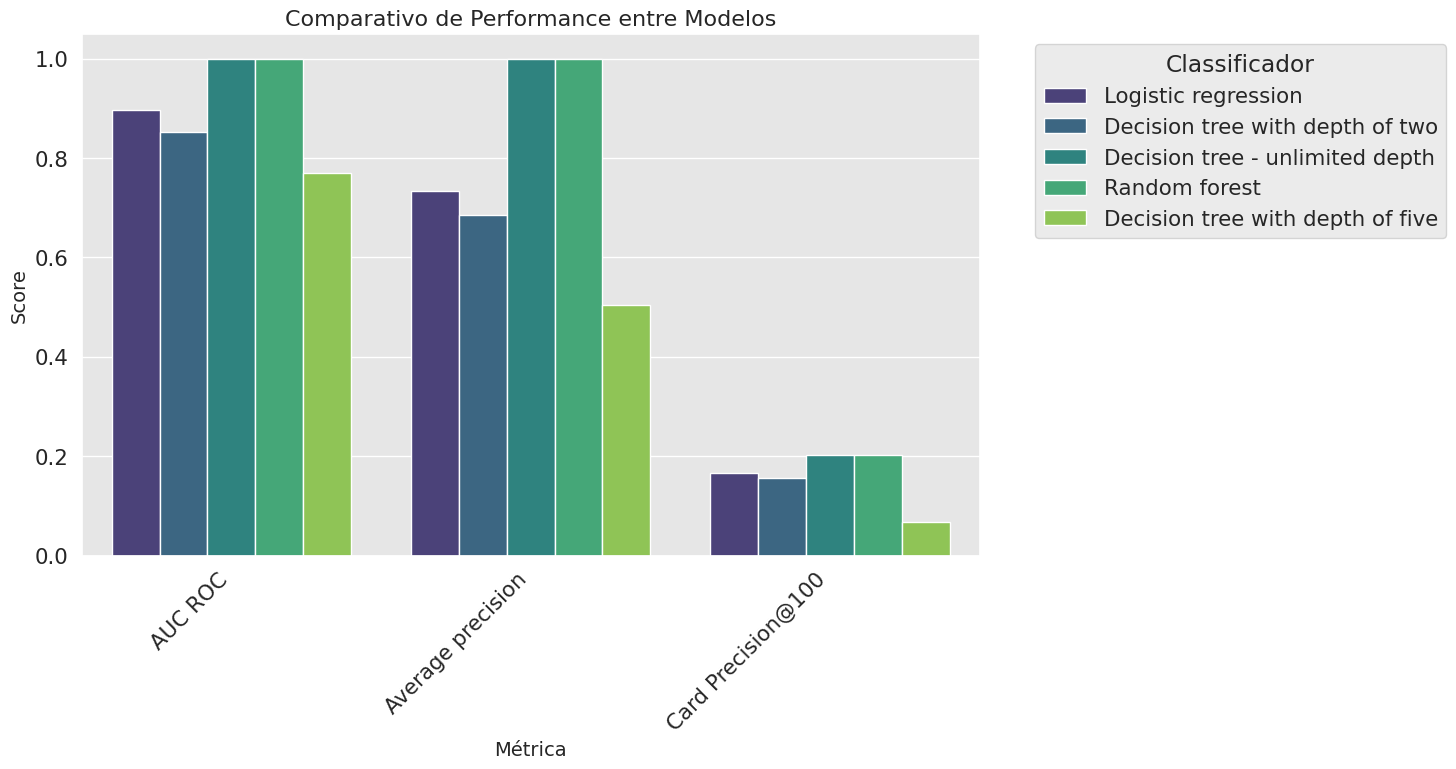

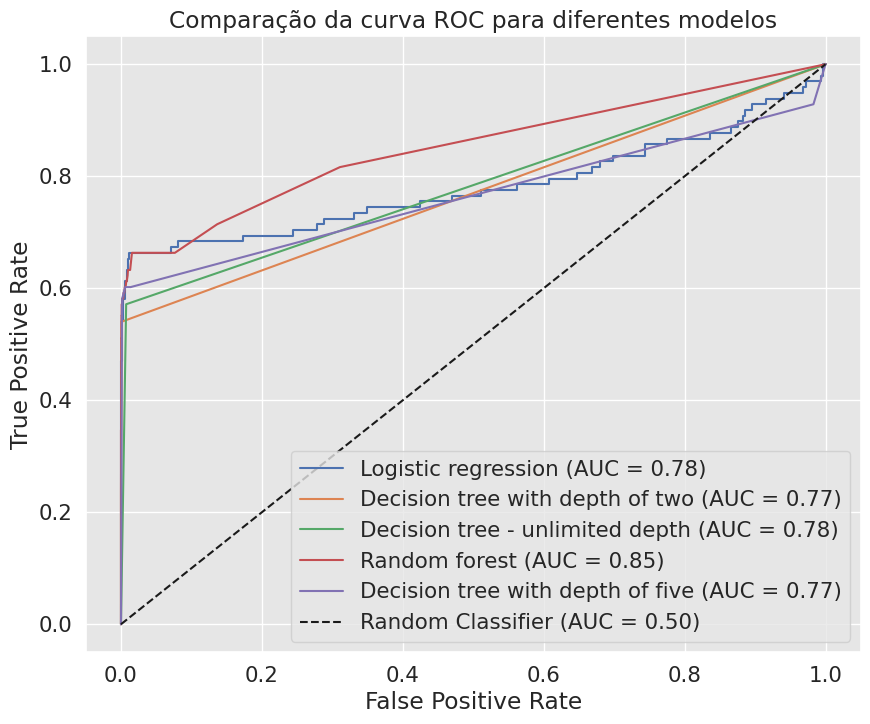

                                  AUC ROC  Average precision  \
Logistic regression                 0.897              0.733   
Decision tree with depth of two     0.852              0.685   
Decision tree - unlimited depth     1.000              1.000   
Random forest                       1.000              1.000   
Decision tree with depth of five    0.770              0.505   

                                  Card Precision@100  
Logistic regression                            0.166  
Decision tree with depth of two                0.156  
Decision tree - unlimited depth                0.203  
Random forest                                  0.203  
Decision tree with depth of five               0.068  



In [137]:
df_performances = performance_assessment_model_collection(fitted_models_and_predictions_dictionary, train_df,
                                                        type_set='train',
                                                        top_k_list=[100])

performances_depth_5 = performance_assessment(predictions_df_depth_5, top_k_list=[100])
performances_depth_5.index = ['Decision tree with depth of five']
df_performances = pd.concat([df_performances, performances_depth_5])

performances_melted = df_performances.reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')
performances_melted = performances_melted.rename(columns={'index': 'Classifier'})

plt.figure(figsize=(15, 8))
sns.barplot(x='Metric', y='Score', hue='Classifier', data=performances_melted, palette='viridis')
plt.title('Comparativo de Performance entre Modelos', fontsize=16)
plt.xlabel('Métrica', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Classificador', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Representando a curva ROC
plt.figure(figsize=(10, 8))

for classifier_name, model_and_predictions in fitted_models_and_predictions_dictionary.items():
    predictions_test = model_and_predictions['predictions_test']

    fpr, tpr, thresholds = roc_curve(test_df['TX_FRAUD'], predictions_test)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{classifier_name} (AUC = {roc_auc:.2f})')

predictions_test_depth_5 = model_and_predictions_depth_5['predictions_test']
fpr_depth_5, tpr_depth_5, thresholds_depth_5 = roc_curve(test_df['TX_FRAUD'], predictions_test_depth_5)
roc_auc_depth_5 = auc(fpr_depth_5, tpr_depth_5)
plt.plot(fpr_depth_5, tpr_depth_5, label=f'Decision tree with depth of five (AUC = {roc_auc_depth_5:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparação da curva ROC para diferentes modelos')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f'{df_performances}')
print('')

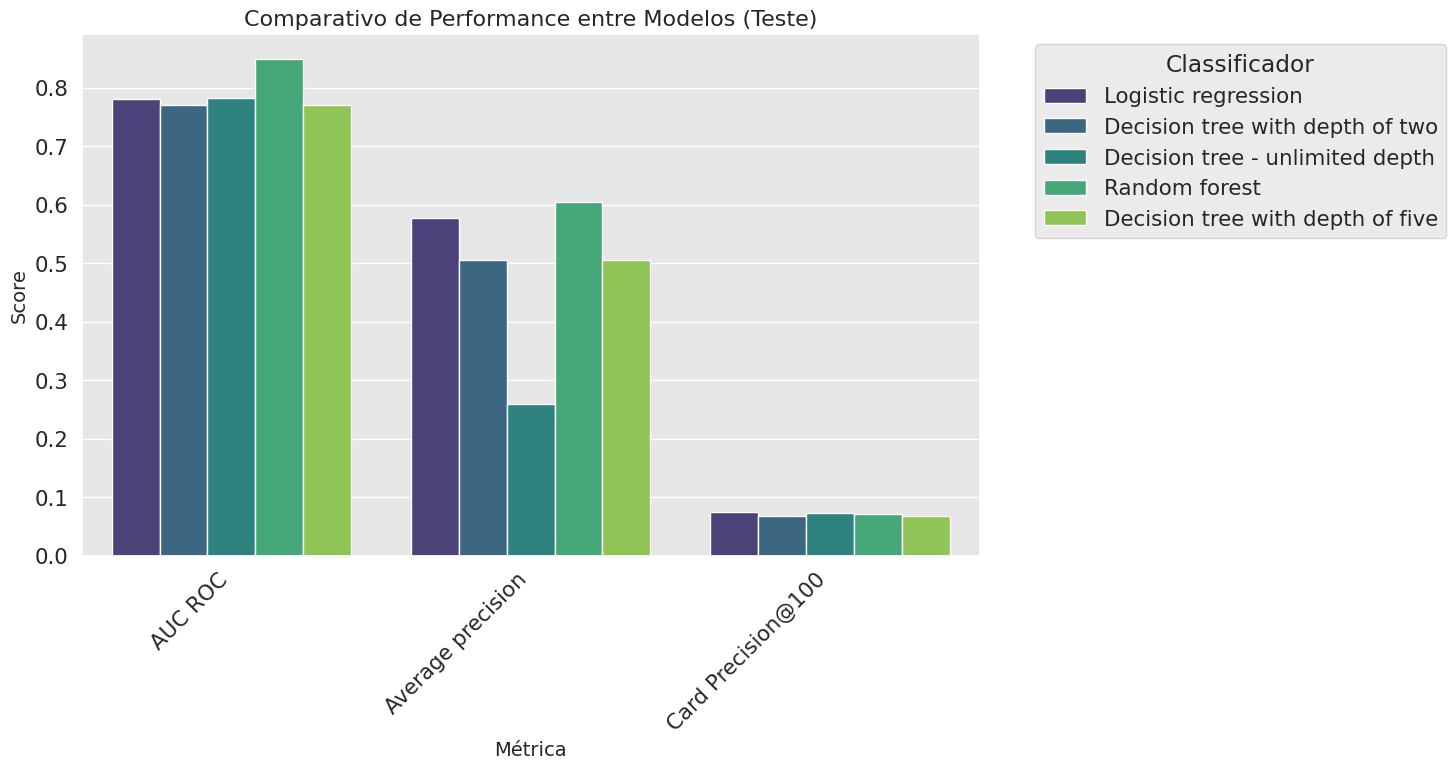

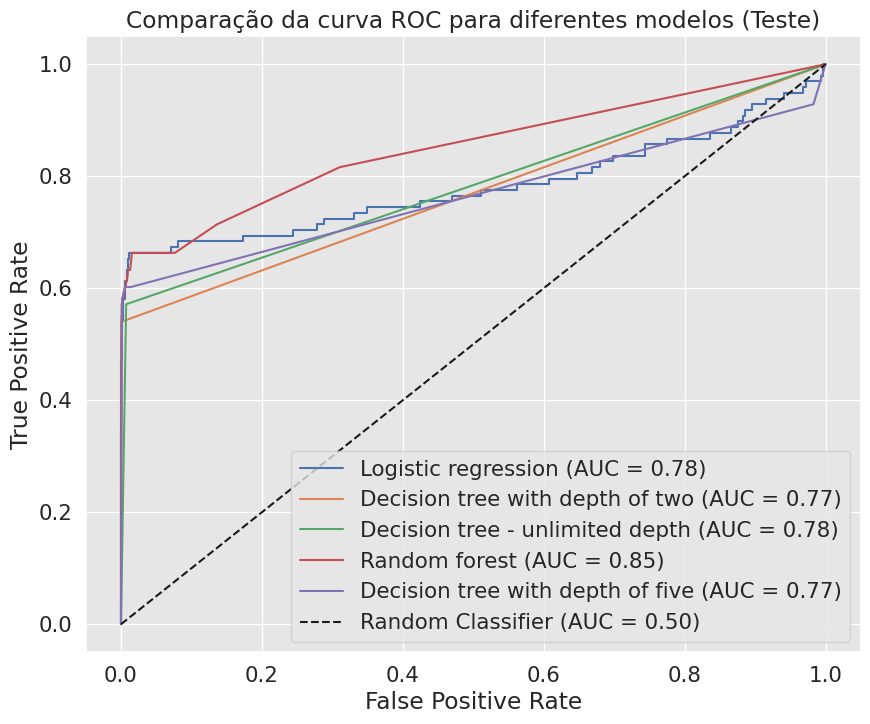

                                  AUC ROC  Average precision  \
Logistic regression                 0.781              0.577   
Decision tree with depth of two     0.770              0.505   
Decision tree - unlimited depth     0.782              0.260   
Random forest                       0.850              0.604   
Decision tree with depth of five    0.770              0.505   

                                  Card Precision@100  
Logistic regression                            0.075  
Decision tree with depth of two                0.068  
Decision tree - unlimited depth                0.073  
Random forest                                  0.072  
Decision tree with depth of five               0.068  
A performance da árvore de decisão com profundidade ilimitada e do random forest caem devido ao overfitting


In [138]:
# Fazendo a mesma comparação com dataset de teste
df_performances_test = performance_assessment_model_collection(fitted_models_and_predictions_dictionary, test_df,
                                                               type_set='test',
                                                               top_k_list=[100])

# Add the Decision Tree with Depth 5 to df_performances_test
performances_depth_5 = performance_assessment(predictions_df_depth_5, top_k_list=[100])
performances_depth_5.index = ['Decision tree with depth of five']
df_performances_test = pd.concat([df_performances_test, performances_depth_5])

performances_test_melted = df_performances_test.reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')
performances_test_melted = performances_test_melted.rename(columns={'index': 'Classifier'})

plt.figure(figsize=(15, 8))
sns.barplot(x='Metric', y='Score', hue='Classifier', data=performances_test_melted, palette='viridis')
plt.title('Comparativo de Performance entre Modelos (Teste)', fontsize=16)
plt.xlabel('Métrica', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Classificador', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))

for classifier_name, model_and_predictions in fitted_models_and_predictions_dictionary.items():
    predictions_test = model_and_predictions['predictions_test']

    fpr, tpr, thresholds = roc_curve(test_df['TX_FRAUD'], predictions_test)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{classifier_name} (AUC = {roc_auc:.2f})')

# Also add the depth 5 tree to the ROC curve plot for the test set
predictions_test_depth_5 = model_and_predictions_depth_5['predictions_test']
fpr_depth_5, tpr_depth_5, thresholds_depth_5 = roc_curve(test_df['TX_FRAUD'], predictions_test_depth_5)
roc_auc_depth_5 = auc(fpr_depth_5, tpr_depth_5)
plt.plot(fpr_depth_5, tpr_depth_5, label=f'Decision tree with depth of five (AUC = {roc_auc_depth_5:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparação da curva ROC para diferentes modelos (Teste)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f'{df_performances_test}')
print('A performance da árvore de decisão com profundidade ilimitada e do random forest caem devido ao overfitting')

#**Conclusão**

Foi treinado um modelo de Machine Learning para detecção de fraudes utilizando uma árvore de decisão. Inicialmente o modelo possuia profundidade 2, mas após melhorias para verificar overfitting ou underfitting, foi feita um modelo com profundidade 5 que possuía maior recall, porém menor precisão.

O maior recall significa que mais casos serão alertados, porém a menor precisão significa que menos desses casos serão corretos. Isso é melhor em casos que há uma segunda camada de verificação, possibilitando que os falsos positivos sejam minimizados.

No final, diferentes modelos foram comparados utilizando ambos os dataset de teste e de treino, sendo feito com os dois datasets para demonstrar o overfitting em certos modelos (Random Forest e Árvore de Decisão com profundidade ilimitada). Todos os modelos testados foram melhores que um modelo aleatório (dito por AUC=0.5), mostrando que a árvore de decisão não é o único modo de fazer um sistema de detecção de fraudes.